In [28]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [29]:
def visualize(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            
            print(cluster_centers)
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                for a in algorithms:
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().cummin().to_frame().reset_index()
                        print(s_min)
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=axes[0]
                        print(axes[0])

                        # Plot the line plot on the first axis

                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1],cmap="YlGnBu", fmt=".3f",norm=mcolors.LogNorm())
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0],cmap='YlGnBu')

                        
                        # Adjust layout
                        plt.tight_layout()
                        if save:
                            file_name=f'{problem}_{a}_run_{run}.pdf'
                            plt.savefig('figures_clustering_new/{file_name}',bbox_inches=0)
                        # Show the combined plot
                        plt.show()
                        
                        '''plt.figure()
                        sns.lineplot(s,x='iteration',y='scaled_raw_y', hue='cluster',palette='tab10')
                        plt.show()
                        
                        plt.figure(figsize=(5,dimension*2))
                        sns.heatmap(df.loc[a,run].T,annot=True)
                        plt.show()'''

In [3]:
def visualize_multi(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False, popsize=50):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            print(cluster_centers)
            cluster_count=cluster_centers.shape[0]
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                fig, all_axes = plt.subplots(len(algorithms), 2 if plot_y else 1, figsize=(cluster_count if plot_y else 10, 3*dimension * len(algorithms)), squeeze=False, sharex=True)
                for a_index, a in enumerate(algorithms):
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().to_frame().reset_index()
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        #fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=all_axes[a_index]

                        # Plot the line plot on the first axis
                        axes[0].set_title(f'Algorithm: {a}; Run: {run}')
                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1], vmin=0, vmax=1)
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0], vmin=0, vmax=popsize,cmap='YlGnBu')

                        
                        # Adjust layout
                
                plt.tight_layout()
                plt.margins(0, tight=True)
                if save:
                    file_name=f"{data_dir.split('/')[-1]}_{problem}_{'+'.join(algorithms)}_run_{'+'.join([str(r) for r in runs])}.pdf"
                    plt.savefig(f'figures_clustering_new/{file_name}',bbox_inches='tight', pad_inches=0)
                # Show the combined plot
                plt.show()

    scaled_x0  scaled_x1
0    1.857723  -2.138437
1    1.338686   1.835168
2    0.126314  -0.381895
3   -4.625543  -1.964231
4    1.775619  -4.243321
5    1.162294  -0.185387
6    1.030650   4.915173
7   -1.739025   3.809758
8    4.620479   0.390355
9    1.254776   2.974754
10   4.016474   4.500112
11  -1.570775  -1.229082
12  -4.652609   3.313509
13   1.349834   0.912270
14   4.697033  -4.783948
15   1.674270  -1.148409
16   1.048843   4.170970
17  -1.586244   1.428774
18  -0.956209  -3.879580
19   2.407107   1.357152
20   1.622062  -0.173652
21   2.656988  -2.932497
22   0.214025   2.565122
23  -4.615228  -4.621337
24   4.563262  -2.133976
25   1.841564  -3.136452
26   4.616930   2.507306
27  -4.624434   0.593396
28   0.798738  -2.445680
29   2.483832  -4.888844
30   2.309564   3.296382
31   2.729866  -0.502053
{0: '1.86, -2.14', 1: '1.34, 1.84', 2: '0.13, -0.38', 3: '-4.63, -1.96', 4: '1.78, -4.24', 5: '1.16, -0.19', 6: '1.03, 4.92', 7: '-1.74, 3.81', 8: '4.62, 0.39', 9: '1.25, 2.97

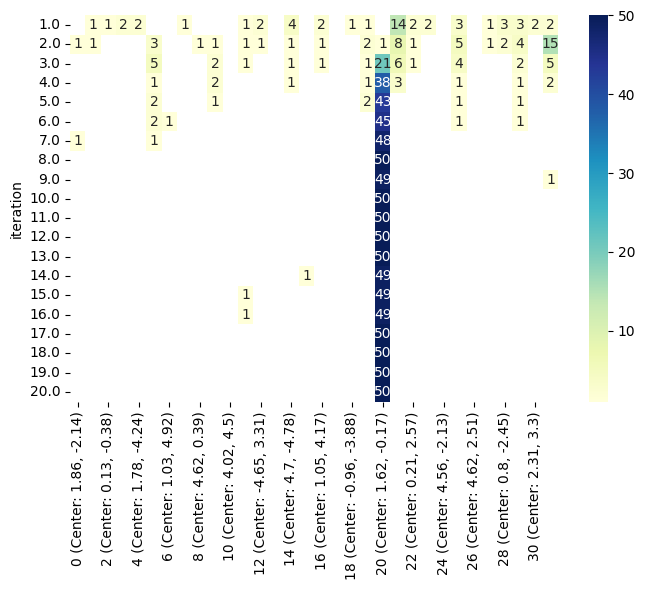

F16_I1 AugmentedAEO 2
     iteration  cluster  scaled_raw_y
0          1.0        1      0.043143
1          1.0        4      0.034272
2          1.0        5      0.034272
3          1.0        6      0.034272
4          1.0        7      0.034272
..         ...      ...           ...
102       16.0       20      0.000001
103       17.0       20      0.000001
104       18.0       20      0.000001
105       19.0       20      0.000001
106       20.0       20      0.000001

[107 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


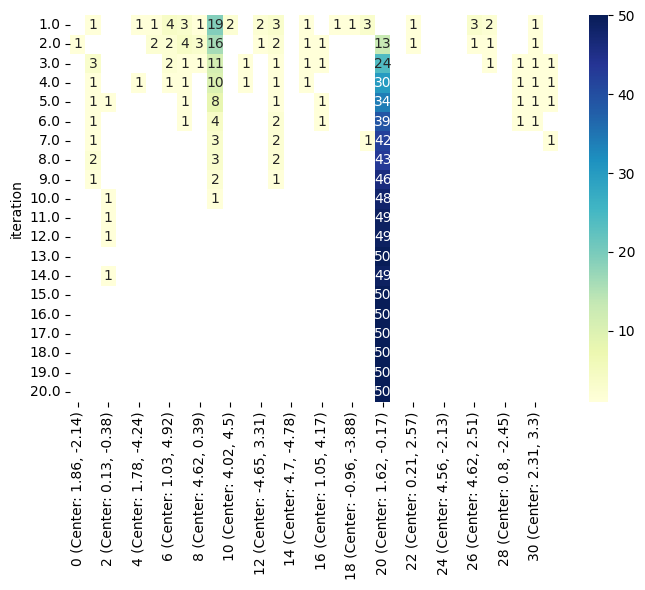

F16_I1 AugmentedAEO 3
    iteration  cluster  scaled_raw_y
0         1.0        1      0.152161
1         1.0        3      0.120319
2         1.0        4      0.099789
3         1.0        6      0.048902
4         1.0        7      0.048902
..        ...      ...           ...
74       18.0       21      0.000000
75       19.0        0      0.000000
76       19.0       15      0.000000
77       20.0        0      0.000000
78       20.0       15      0.000000

[79 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


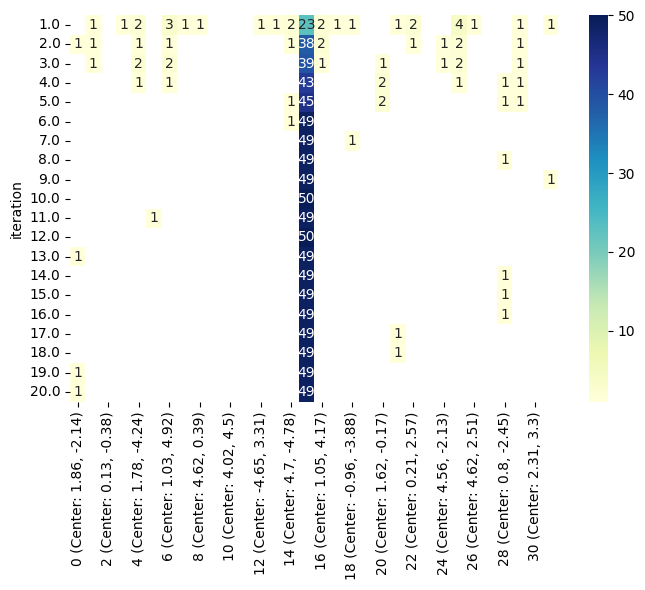

F16_I1 AugmentedAEO 4
    iteration  cluster  scaled_raw_y
0         1.0        1      0.007745
1         1.0        3      0.007745
2         1.0        6      0.007745
3         1.0        7      0.007745
4         1.0        8      0.007745
..        ...      ...           ...
64       16.0        1      0.000000
65       17.0        1      0.000000
66       18.0        1      0.000000
67       19.0        1      0.000000
68       20.0        1      0.000000

[69 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


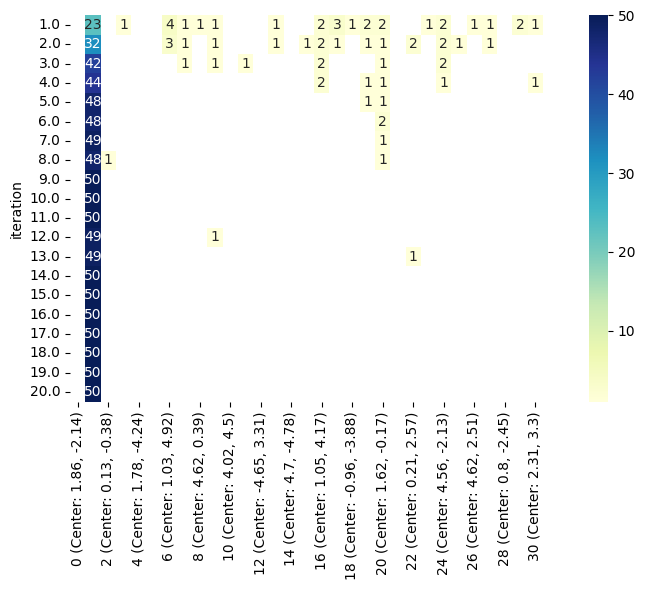

F16_I1 AugmentedAEO 5
    iteration  cluster  scaled_raw_y
0         1.0        1      0.013008
1         1.0        6      0.013008
2         1.0        7      0.013008
3         1.0        9      0.001172
4         1.0       11      0.001172
..        ...      ...           ...
77       16.0        9      0.000000
78       17.0        9      0.000000
79       18.0        9      0.000000
80       19.0        9      0.000000
81       20.0        9      0.000000

[82 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


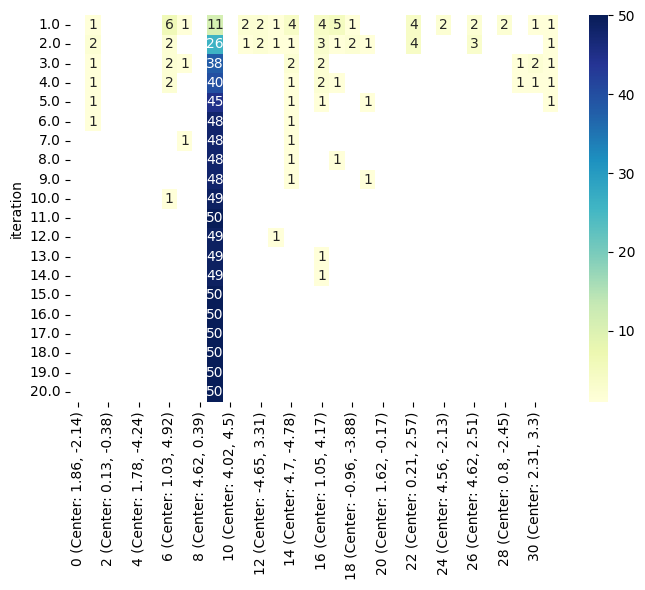

F16_I1 OriginalDE 1
     iteration  cluster  scaled_raw_y
0          1.0        1      0.031729
1          1.0        2      0.031729
2          1.0        4      0.031729
3          1.0        5      0.031729
4          1.0        7      0.031729
..         ...      ...           ...
166       20.0        9      0.000018
167       20.0       13      0.000003
168       20.0       15      0.000003
169       20.0       16      0.000003
170       20.0       20      0.000003

[171 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


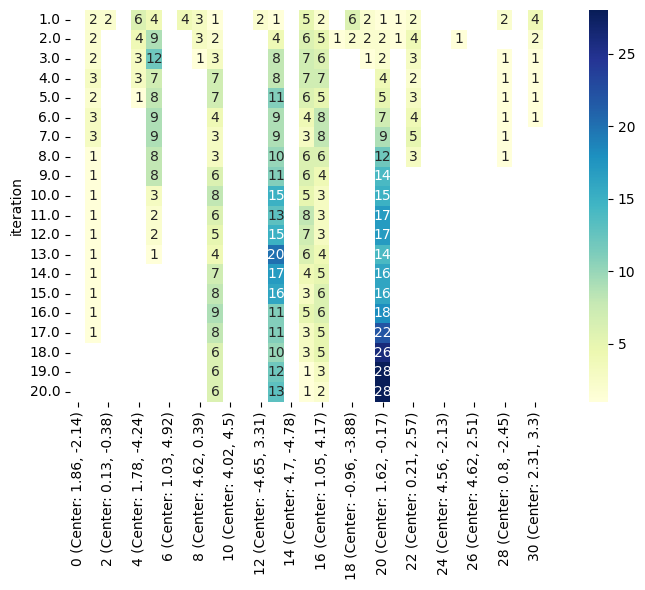

F16_I1 OriginalDE 2
     iteration  cluster  scaled_raw_y
0          1.0        1  6.556903e-02
1          1.0        3  6.556903e-02
2          1.0        4  6.556903e-02
3          1.0        5  6.556903e-02
4          1.0        7  6.556903e-02
..         ...      ...           ...
120       16.0       20  4.068499e-06
121       17.0       20  5.200614e-07
122       18.0       20  7.403440e-08
123       19.0       20  2.544884e-08
124       20.0       20  2.312518e-08

[125 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


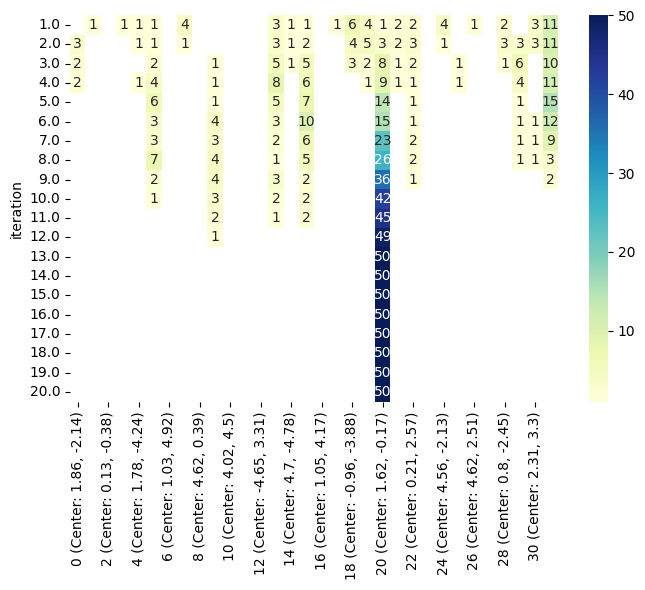

F16_I1 OriginalDE 3
     iteration  cluster  scaled_raw_y
0          1.0        0      0.070167
1          1.0        2      0.040473
2          1.0        4      0.040473
3          1.0        6      0.040473
4          1.0        7      0.040473
..         ...      ...           ...
170       19.0       16      0.000003
171       20.0        1      0.000003
172       20.0        9      0.000003
173       20.0       13      0.000003
174       20.0       16      0.000003

[175 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


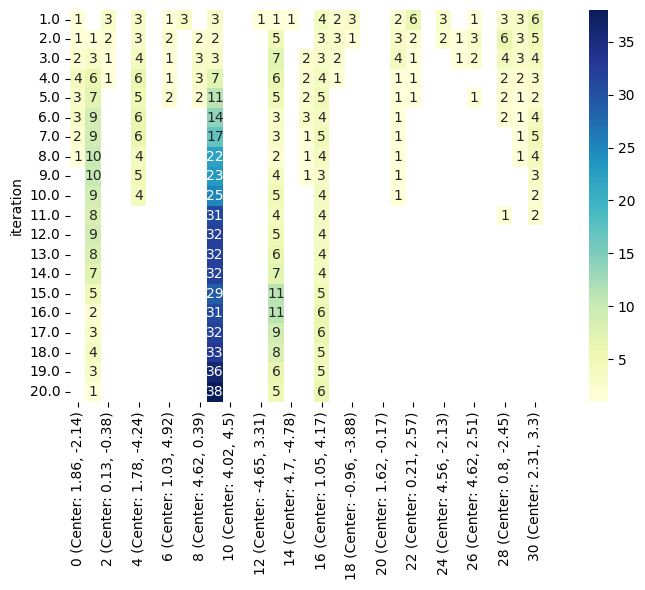

F16_I1 OriginalDE 4
     iteration  cluster  scaled_raw_y
0          1.0        0      0.021801
1          1.0        3      0.021801
2          1.0        4      0.021801
3          1.0        5      0.016243
4          1.0        6      0.016243
..         ...      ...           ...
231       20.0       13      0.000007
232       20.0       15      0.000007
233       20.0       16      0.000007
234       20.0       20      0.000007
235       20.0       25      0.000007

[236 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


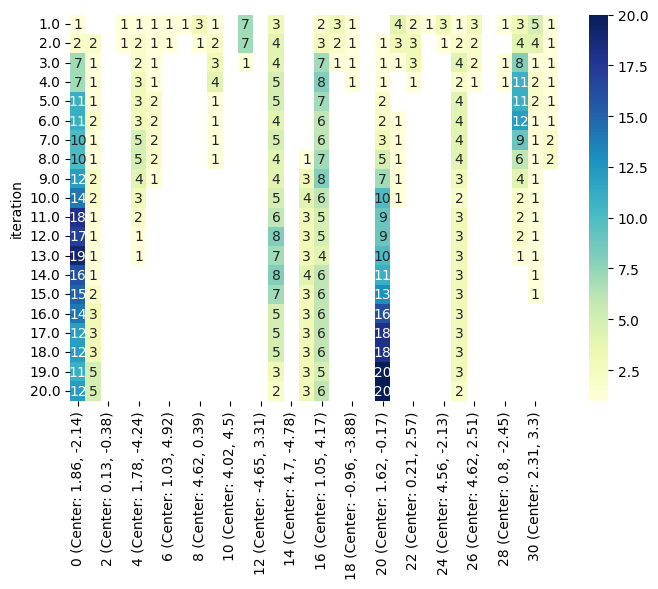

F16_I1 OriginalDE 5
     iteration  cluster  scaled_raw_y
0          1.0        1      0.108469
1          1.0        3      0.108469
2          1.0        6      0.060295
3          1.0        7      0.060295
4          1.0        8      0.060295
..         ...      ...           ...
200       20.0        9      0.000009
201       20.0       13      0.000009
202       20.0       15      0.000004
203       20.0       16      0.000004
204       20.0       20      0.000004

[205 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


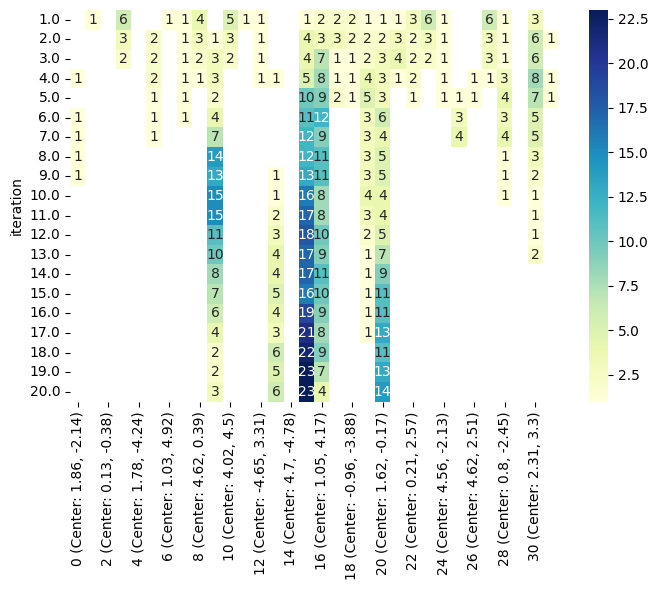

In [9]:
visualize([2], ['F16_I1'], ['AugmentedAEO','OriginalDE'], [1,2,3,4, 5], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', plot_y=False)

               x0        x1
cluster                    
0        1.709259 -1.142557
1        1.258431  2.973927
2        1.589015 -0.178762
3        1.433309  0.915482
4        1.076292  4.193510
5        1.364855  1.841303
6        0.559894  2.952757
7        2.350101 -0.154595
8        1.049801 -2.157563
9        0.783891  1.840570
10       1.835937 -2.146308
11       2.085307 -4.141655
12       2.223270 -4.993557
13       2.063393 -3.144603
14       2.700718 -3.136149
15       0.977218  4.995499
16       3.152741 -4.999705
17       5.000000 -5.000000
18       1.559202 -3.124418
19       0.083573  2.910073
20       2.177037  0.928030
{0: '1.71, -1.14', 1: '1.26, 2.97', 2: '1.59, -0.18', 3: '1.43, 0.92', 4: '1.08, 4.19', 5: '1.36, 1.84', 6: '0.56, 2.95', 7: '2.35, -0.15', 8: '1.05, -2.16', 9: '0.78, 1.84', 10: '1.84, -2.15', 11: '2.09, -4.14', 12: '2.22, -4.99', 13: '2.06, -3.14', 14: '2.7, -3.14', 15: '0.98, 5.0', 16: '3.15, -5.0', 17: '5.0, -5.0', 18: '1.56, -3.12', 19: '0.08, 2.91'

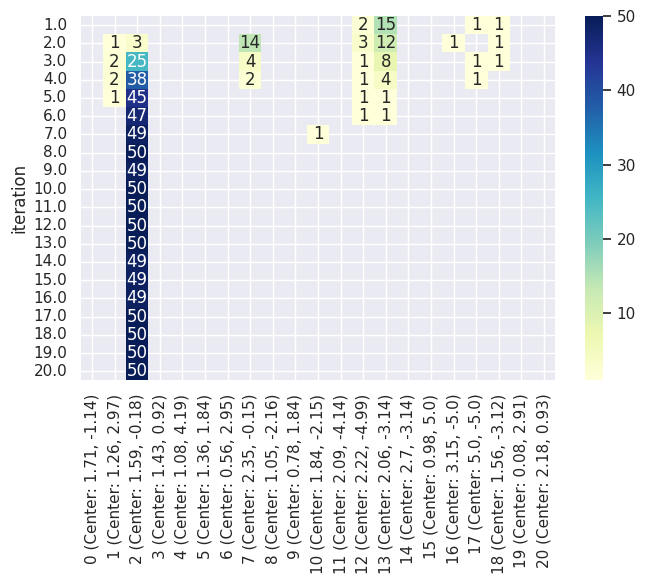

F16_I1 AugmentedAEO 2
    iteration  cluster  scaled_raw_y
0         1.0        1      0.001852
1         1.0        3      0.001268
2         1.0       11      0.001268
3         1.0       15      0.001268
4         1.0       21      0.001268
..        ...      ...           ...
70       16.0        2      0.000001
71       17.0        2      0.000001
72       18.0        2      0.000001
73       19.0        2      0.000001
74       20.0        2      0.000001

[75 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


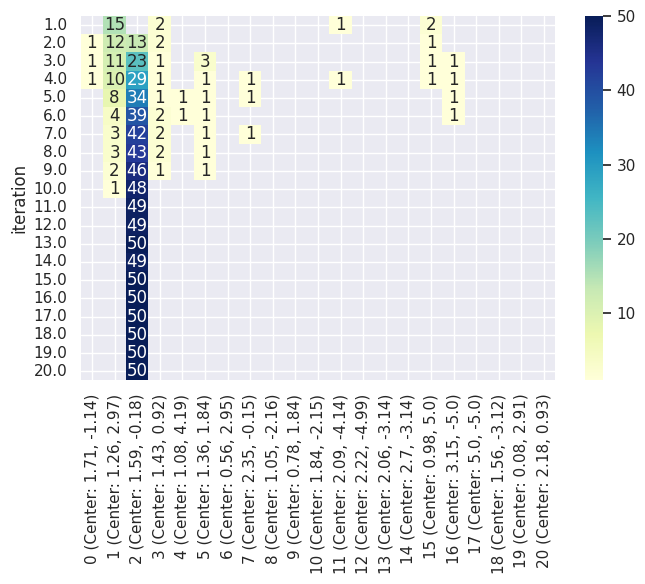

F16_I1 AugmentedAEO 3
    iteration  cluster  scaled_raw_y
0         1.0        0  6.089659e-04
1         1.0        4  6.089659e-04
2         1.0       15  6.089659e-04
3         1.0       17  6.089659e-04
4         1.0       18  6.089659e-04
5         1.0       21  6.089659e-04
6         2.0        0  1.472753e-04
7         2.0        4  1.472753e-04
8         2.0        5  1.472753e-04
9         2.0       16  1.472753e-04
10        2.0       18  1.472753e-04
11        2.0       21  1.472753e-04
12        3.0        0  1.345288e-05
13        3.0        4  1.345288e-05
14        3.0       16  1.345288e-05
15        3.0       18  1.345288e-05
16        3.0       21  1.345288e-05
17        4.0        0  4.701379e-06
18        4.0        2  4.701379e-06
19        4.0       16  4.701379e-06
20        4.0       18  4.701379e-06
21        4.0       21  4.701379e-06
22        5.0        0  1.377236e-06
23        5.0        2  1.377236e-06
24        5.0       16  1.377236e-06
25        5.0   

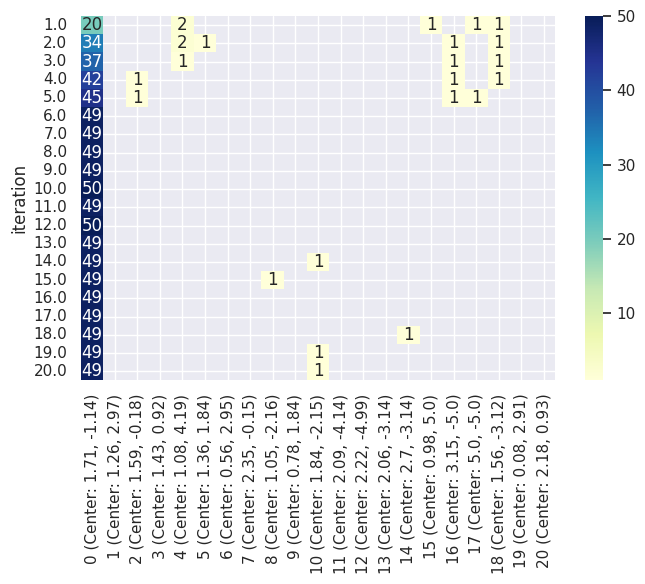

F16_I1 AugmentedAEO 4
    iteration  cluster  scaled_raw_y
0         1.0        1  1.255847e-02
1         1.0        4  1.255847e-02
2         1.0        5  7.745279e-03
3         1.0       21  7.745279e-03
4         2.0        0  7.745279e-03
5         2.0        1  7.745279e-03
6         2.0        2  4.379950e-03
7         2.0        4  4.379950e-03
8         2.0        5  2.347510e-04
9         2.0       21  2.347510e-04
10        3.0        1  2.347510e-04
11        3.0        2  2.347510e-04
12        3.0        4  2.347510e-04
13        3.0        5  1.170971e-04
14        3.0       21  1.170971e-04
15        4.0        2  1.170971e-04
16        4.0        4  1.170971e-04
17        4.0        5  8.292326e-05
18        4.0       21  8.292326e-05
19        5.0        2  8.292326e-05
20        5.0        5  7.842489e-05
21        5.0       21  7.842489e-05
22        6.0        2  7.842489e-05
23        6.0        5  7.634222e-05
24        7.0        2  7.634222e-05
25        7.0   

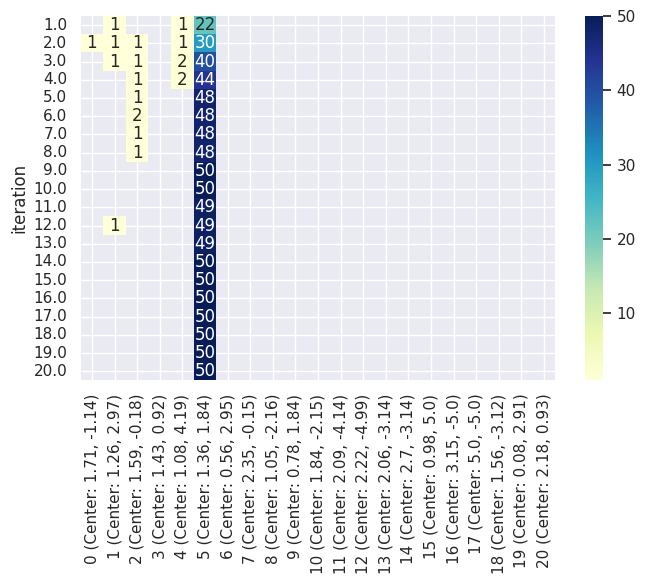

F16_I1 AugmentedAEO 5
    iteration  cluster  scaled_raw_y
0         1.0        1  1.171660e-03
1         1.0        5  1.171660e-03
2         1.0        6  1.171660e-03
3         1.0        8  1.171660e-03
4         1.0       15  1.171660e-03
5         1.0       17  1.171660e-03
6         1.0       21  1.171660e-03
7         2.0        1  4.357947e-04
8         2.0        5  4.357947e-04
9         2.0        6  4.357947e-04
10        2.0       15  4.357947e-04
11        2.0       21  4.357947e-04
12        3.0        1  1.871665e-04
13        3.0        5  1.871665e-04
14        3.0       17  1.871665e-04
15        3.0       21  1.871665e-04
16        4.0        1  4.062006e-05
17        4.0        4  4.062006e-05
18        4.0       15  4.062006e-05
19        4.0       21  4.062006e-05
20        5.0        1  2.214421e-06
21        5.0        4  2.214421e-06
22        5.0       21  2.214421e-06
23        6.0        1  6.723140e-07
24        6.0       21  6.723140e-07
25        7.0   

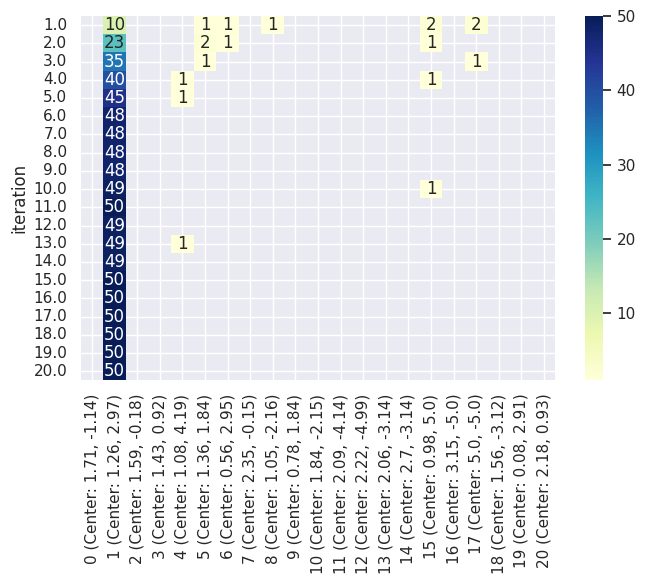

F16_I1 OriginalDE 1
     iteration  cluster  scaled_raw_y
0          1.0        0      0.046934
1          1.0        1      0.008766
2          1.0        2      0.008766
3          1.0        3      0.008766
4          1.0       19      0.008766
..         ...      ...           ...
120       20.0        0      0.000018
121       20.0        1      0.000018
122       20.0        2      0.000018
123       20.0        3      0.000003
124       20.0        4      0.000003

[125 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


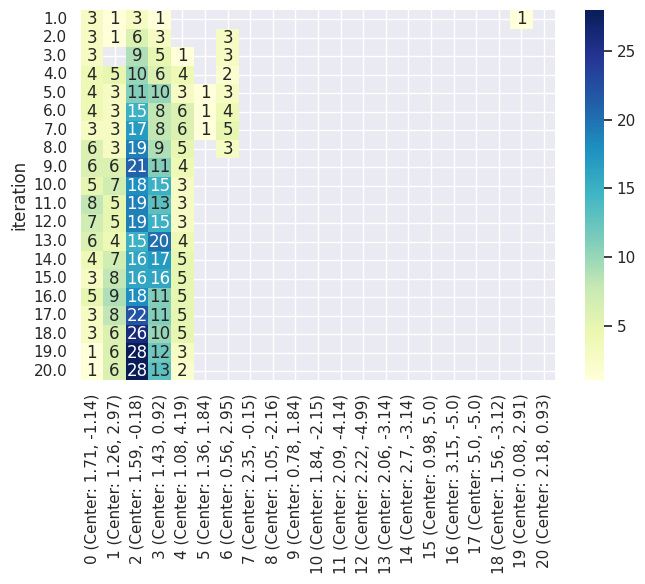

F16_I1 OriginalDE 2
    iteration  cluster  scaled_raw_y
0         1.0        0  2.230590e-02
1         1.0        2  2.230590e-02
2         1.0        3  2.230590e-02
3         1.0       21  2.230590e-02
4         2.0        0  2.230590e-02
..        ...      ...           ...
64       16.0        2  4.068499e-06
65       17.0        2  5.200614e-07
66       18.0        2  7.403440e-08
67       19.0        2  2.544884e-08
68       20.0        2  2.312518e-08

[69 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


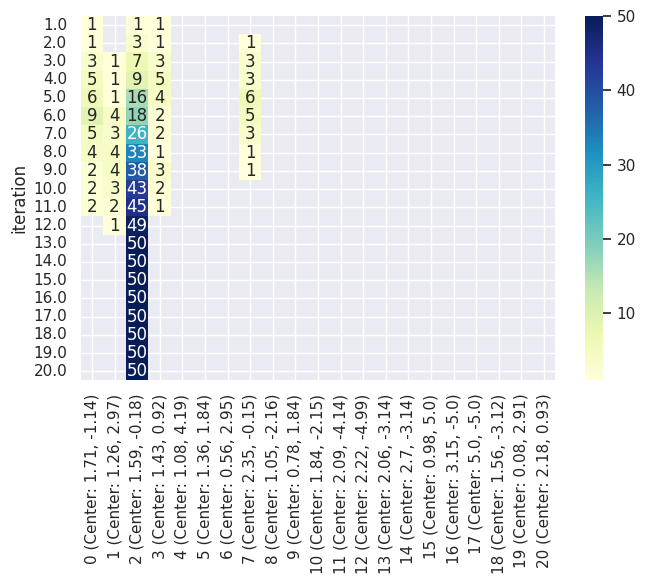

F16_I1 OriginalDE 3
     iteration  cluster  scaled_raw_y
0          1.0        1      0.006272
1          1.0        3      0.006272
2          1.0       21      0.006272
3          2.0        1      0.006272
4          2.0        3      0.001590
..         ...      ...           ...
102       19.0        5      0.000003
103       20.0        1      0.000003
104       20.0        3      0.000003
105       20.0        4      0.000003
106       20.0        5      0.000003

[107 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


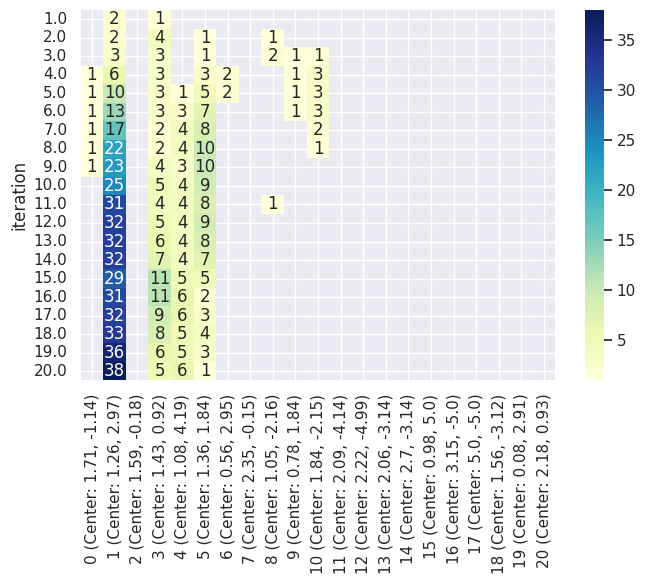

F16_I1 OriginalDE 4
     iteration  cluster  scaled_raw_y
0          1.0        4      0.019982
1          1.0       10      0.019982
2          1.0       13      0.019982
3          1.0       21      0.011626
4          2.0        1      0.011626
..         ...      ...           ...
175       20.0        3      0.000007
176       20.0        4      0.000007
177       20.0        5      0.000007
178       20.0       10      0.000007
179       20.0       13      0.000007

[180 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


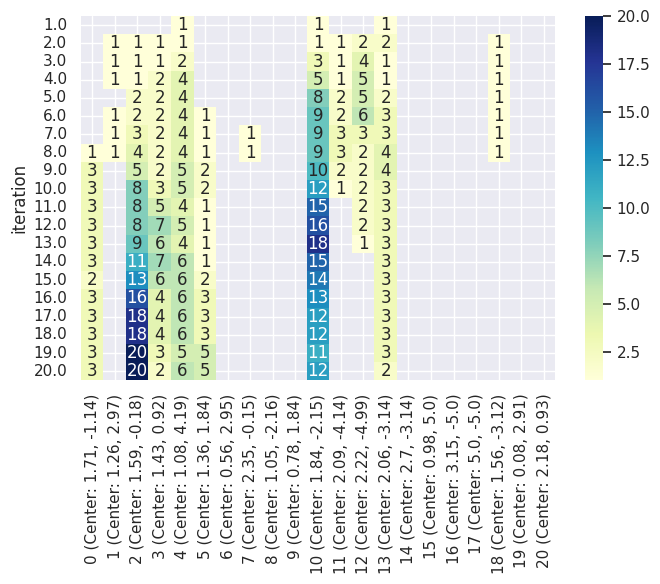

F16_I1 OriginalDE 5
     iteration  cluster  scaled_raw_y
0          1.0        0      0.060748
1          1.0        2      0.033670
2          1.0       15      0.033670
3          1.0       20      0.003527
4          1.0       21      0.003527
..         ...      ...           ...
124       20.0        0      0.000004
125       20.0        1      0.000004
126       20.0        2      0.000004
127       20.0        3      0.000004
128       20.0        4      0.000004

[129 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


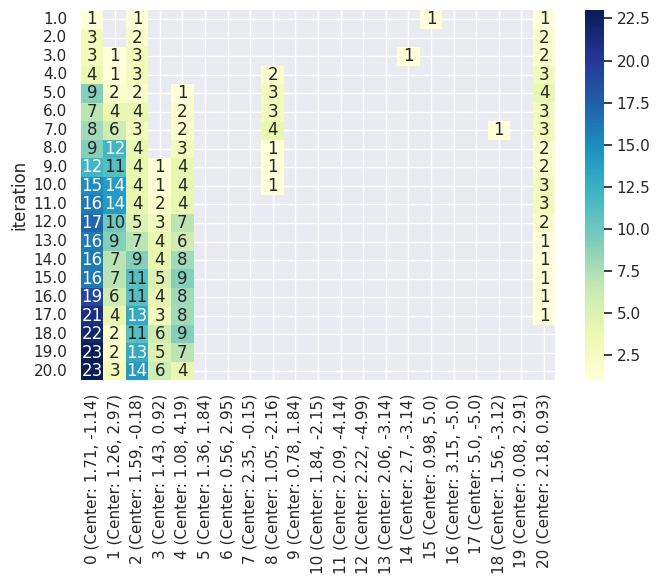

In [26]:
algorithms_of_interest=["ModifiedAEO",
"OriginalAEO",
"AugmentedAEO",
"OriginalSHADE",
"SADE",
"JADE",
"OriginalDE",
"OriginalWOA",
"HI_WOA"]

visualize([2], ['F16_I1'], ['AugmentedAEO', 'OriginalDE'], [1, 2, 3, 4, 5],data_dir=f'test_data', plot_y=False)

    scaled_x0  scaled_x1
0   -1.329093   1.428670
1   -4.538486  -3.480184
2   -3.782924   0.661374
3    2.279349  -0.159496
4   -2.166210  -0.380001
5    3.155546  -3.991431
6    0.576405   3.107079
7   -3.174017  -4.327252
8    4.569192   0.604639
9   -4.956394  -4.962658
10  -3.067228   0.898775
11  -1.503715   4.413642
12   0.177886  -0.997564
13  -4.290876   0.498781
14  -3.110208  -2.190902
15  -4.493786  -1.159633
16   2.070974   1.945983
17  -0.517095   2.816850
18  -3.450069   3.258853
19  -2.011726  -1.848942
20   3.955556   2.520626
21   0.853538   4.614357
22   1.090820  -3.885356
23   0.562975   1.983316
24  -1.042607  -1.444152
25  -4.881671  -4.488722
26  -4.918133   0.308651
27  -4.464575  -4.555865
28   3.521977   0.226478
29  -2.259128   1.133123
30  -0.347131   1.611885
31  -0.200310   4.110777
{0: '-1.33, 1.43', 1: '-4.54, -3.48', 2: '-3.78, 0.66', 3: '2.28, -0.16', 4: '-2.17, -0.38', 5: '3.16, -3.99', 6: '0.58, 3.11', 7: '-3.17, -4.33', 8: '4.57, 0.6', 9: '-4.96, -

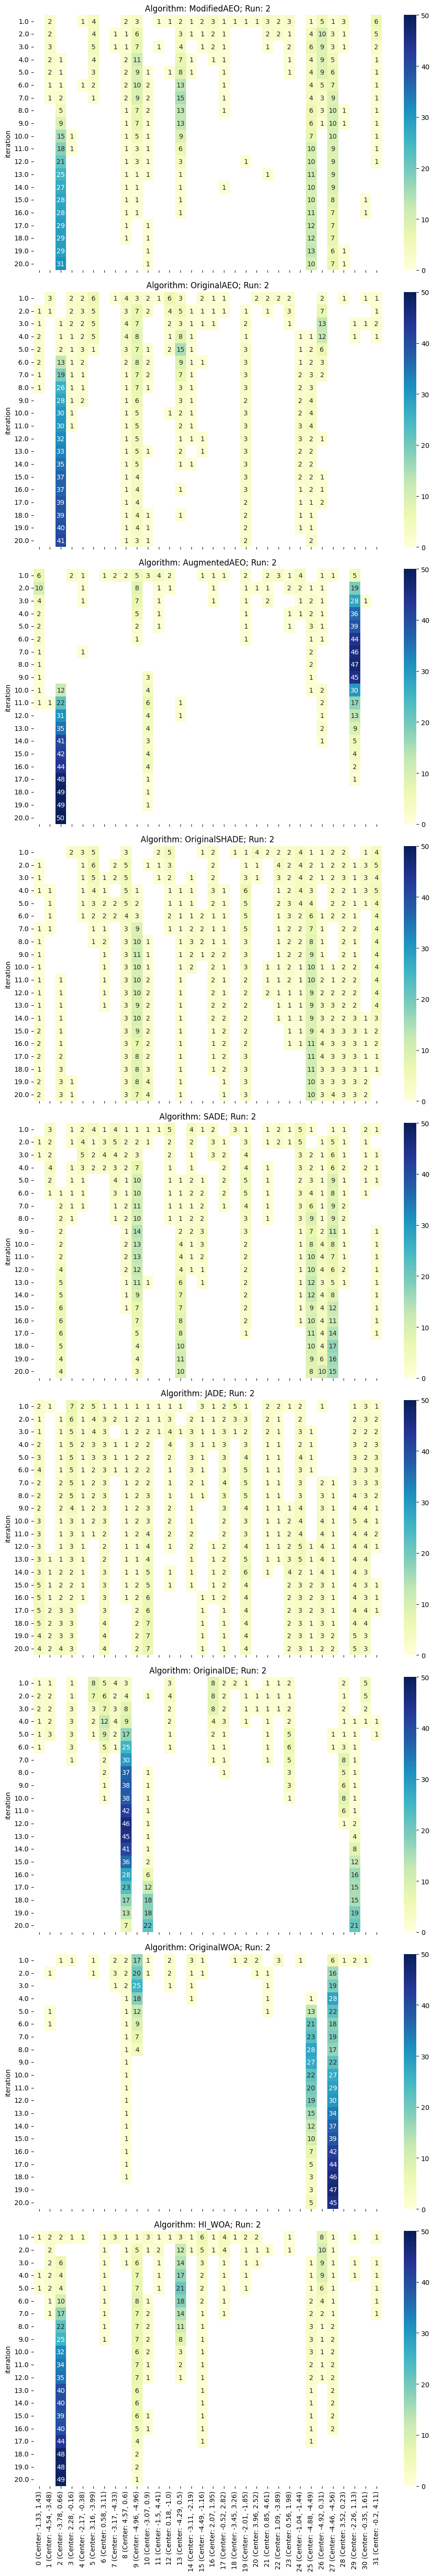

In [11]:
visualize_multi([2], ['F22_I4'], algorithms_of_interest, [2], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', save=False)

    scaled_x0  scaled_x1
0    2.276319  -1.527480
1    0.914602   1.604890
2   -2.142801  -3.781699
3   -2.482464   0.144400
4    1.988105   3.927928
5    2.945194  -3.052699
6    1.334384   0.735914
7   -1.555206  -2.218418
8   -0.552729   4.548644
9    0.081141  -4.597776
10   4.402608   3.899582
11   2.656933  -2.236665
12  -3.666853   1.522367
13   1.738697  -0.144546
14  -4.541574  -0.368180
15   3.572030   4.834334
16   0.439542   2.587299
17  -2.459405  -4.578960
18   4.616012  -1.934759
19  -3.539941  -2.319451
20  -1.848238  -0.998550
21  -0.864827  -3.243670
22   1.521993  -3.809646
23   3.190375   2.454156
24   3.748279  -4.453520
25  -1.316342  -4.429041
26  -4.549381   3.851943
27   0.045331   3.400177
28   1.988038  -0.745082
29  -3.702313  -4.546717
30   1.521055   0.317367
31  -1.268657   2.264139
{0: '2.28, -1.53', 1: '0.91, 1.6', 2: '-2.14, -3.78', 3: '-2.48, 0.14', 4: '1.99, 3.93', 5: '2.95, -3.05', 6: '1.33, 0.74', 7: '-1.56, -2.22', 8: '-0.55, 4.55', 9: '0.08, -4.6

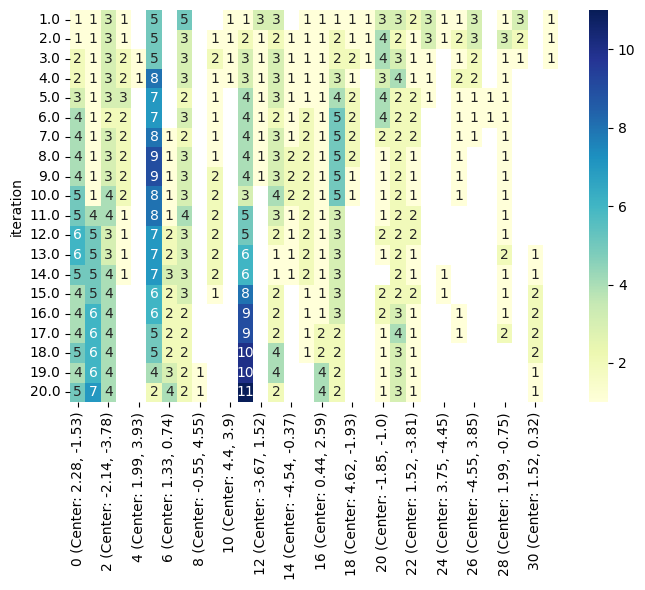

F22_I1 JADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0  7.907423e-02
1          1.0        1  1.448633e-04
2          1.0        2  1.448633e-04
3          1.0        3  1.448633e-04
4          1.0        4  1.448633e-04
..         ...      ...           ...
424       20.0       17  2.936462e-07
425       20.0       19  2.936462e-07
426       20.0       27  2.936462e-07
427       20.0       28  2.936462e-07
428       20.0       30  2.936462e-07

[429 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


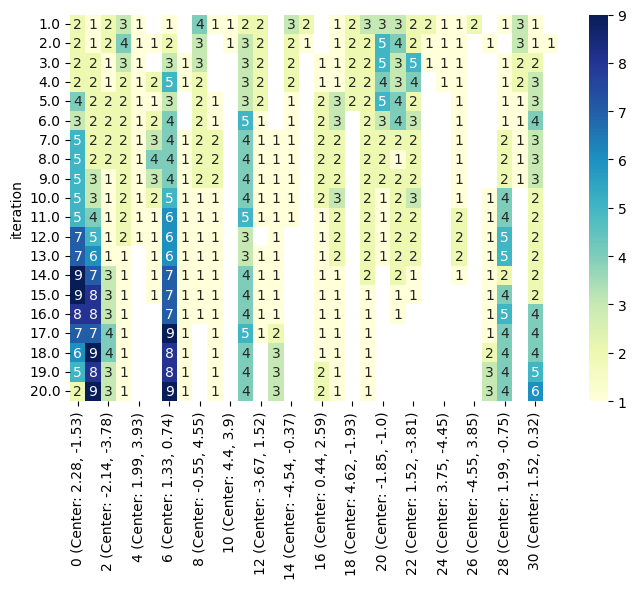

F22_I1 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  8.537303e-02
1          1.0        1  8.537303e-02
2          1.0        3  7.832217e-02
3          1.0        4  7.832217e-02
4          1.0        7  7.832217e-02
..         ...      ...           ...
439       20.0       22  5.226475e-07
440       20.0       25  5.226475e-07
441       20.0       27  5.226475e-07
442       20.0       28  5.226475e-07
443       20.0       30  5.226475e-07

[444 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


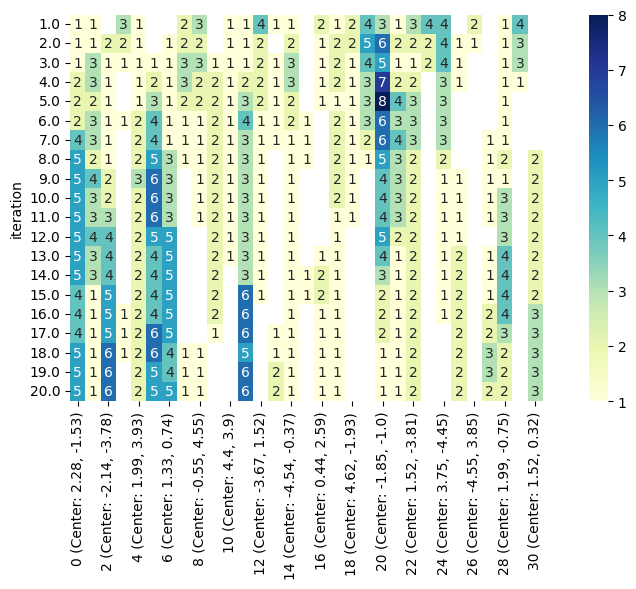

F22_I1 SADE 1
     iteration  cluster  scaled_raw_y
0          1.0        0  5.562651e-03
1          1.0        2  5.562651e-03
2          1.0        3  5.562651e-03
3          1.0        4  5.562651e-03
4          1.0        5  5.562651e-03
..         ...      ...           ...
394       20.0       16  8.971728e-07
395       20.0       19  8.971728e-07
396       20.0       27  8.971728e-07
397       20.0       28  8.971728e-07
398       20.0       30  8.971728e-07

[399 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


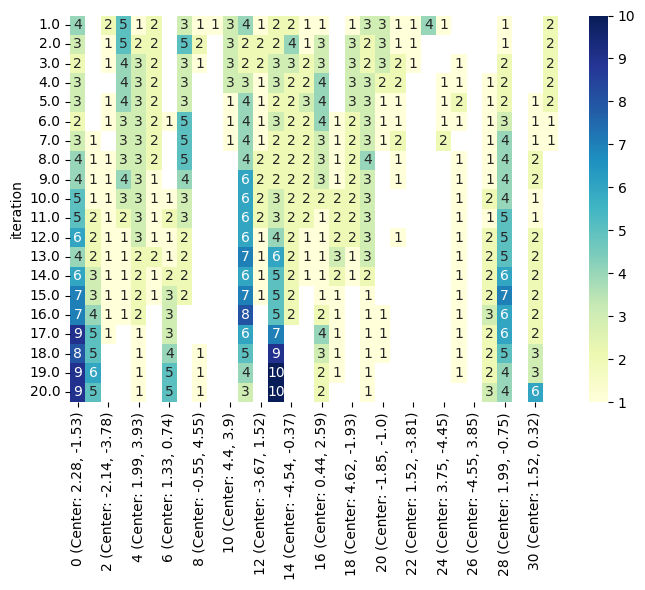

F22_I1 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.585550
1          1.0        1      0.005585
2          1.0        2      0.005585
3          1.0        3      0.005585
4          1.0        4      0.005585
..         ...      ...           ...
358       20.0       16      0.000001
359       20.0       17      0.000001
360       20.0       27      0.000001
361       20.0       28      0.000001
362       20.0       30      0.000001

[363 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


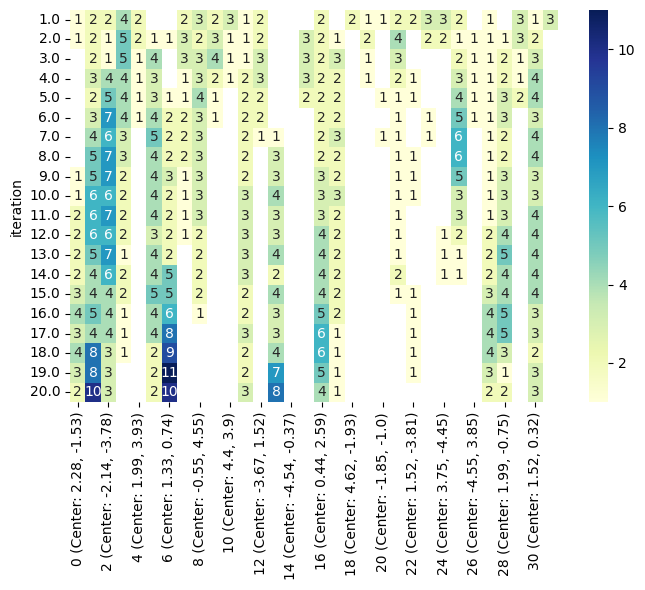

F22_I1 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  4.771002e-01
1          1.0        1  1.961448e-01
2          1.0        2  1.176469e-01
3          1.0        3  1.176469e-01
4          1.0        4  1.176469e-01
..         ...      ...           ...
382       20.0       22  5.236849e-07
383       20.0       25  5.236849e-07
384       20.0       27  5.236849e-07
385       20.0       28  5.236849e-07
386       20.0       30  5.236849e-07

[387 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


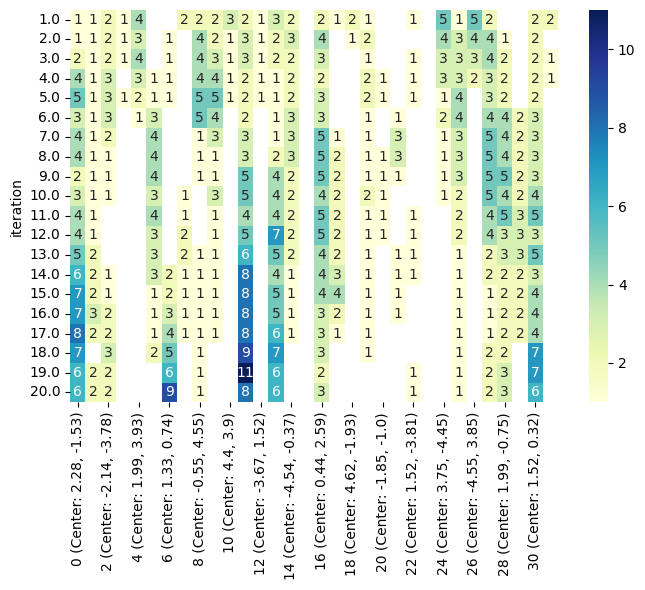

In [ ]:
visualize([2], ['F22_I1'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_10_algorithms_kmeans_2pow_no_init', plot_y=False)

               x0        x1
cluster                    
0        1.729852 -0.107014
1       -2.108146 -4.064414
2        3.137685 -2.926323
3        3.013816 -2.712674
4        2.076122 -1.567749
5        0.342436  2.794042
6        0.196607  3.127413
7       -0.776240  4.990246
8       -0.468697  4.420479
9        3.695253  4.979582
10       1.372527 -3.863461
11       1.786065 -3.709730
{0: '1.73, -0.11', 1: '-2.11, -4.06', 2: '3.14, -2.93', 3: '3.01, -2.71', 4: '2.08, -1.57', 5: '0.34, 2.79', 6: '0.2, 3.13', 7: '-0.78, 4.99', 8: '-0.47, 4.42', 9: '3.7, 4.98', 10: '1.37, -3.86', 11: '1.79, -3.71'}
F22_I1 JADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0      0.000695
1         1.0        1      0.000695
2         1.0       12      0.000695
3         2.0        0      0.000695
4         2.0        1      0.000695
..        ...      ...           ...
67       19.0        1      0.000028
68       19.0       12      0.000028
69       20.0        0      0.000028
70       

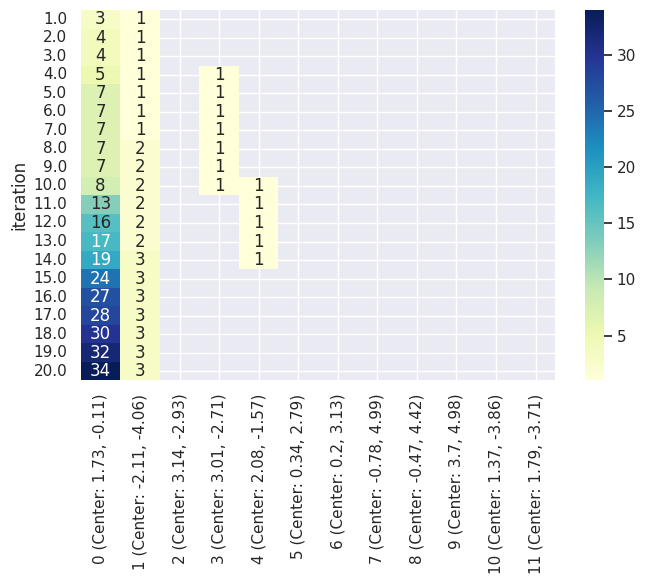

F22_I1 JADE 2
    iteration  cluster  scaled_raw_y
0         1.0        0  1.448633e-04
1         1.0       12  1.448633e-04
2         2.0        0  1.448633e-04
3         2.0       12  1.448633e-04
4         3.0        0  3.646967e-05
5         3.0       12  3.646967e-05
6         4.0        0  3.646967e-05
7         4.0       12  3.646967e-05
8         5.0        0  3.646967e-05
9         5.0        4  3.646967e-05
10        5.0       12  3.646967e-05
11        6.0        0  2.936462e-07
12        6.0        4  2.936462e-07
13        6.0       12  2.936462e-07
14        7.0        0  2.936462e-07
15        7.0        4  2.936462e-07
16        7.0       12  2.936462e-07
17        8.0        0  2.936462e-07
18        8.0        4  2.936462e-07
19        8.0       12  2.936462e-07
20        9.0        0  2.936462e-07
21        9.0        4  2.936462e-07
22        9.0       12  2.936462e-07
23       10.0        0  2.936462e-07
24       10.0        4  2.936462e-07
25       10.0       12  

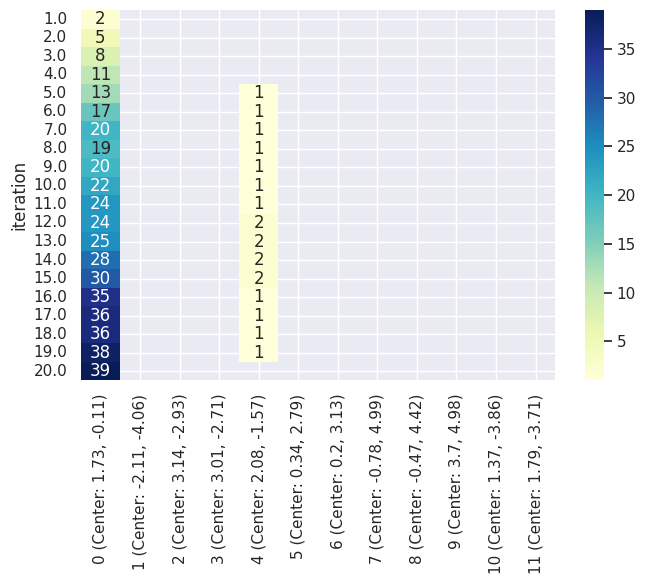

F22_I1 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0       12  1.664504e-02
1          2.0        0  1.664504e-02
2          2.0       12  1.664504e-02
3          3.0        0  9.735603e-04
4          3.0       12  9.735603e-04
..         ...      ...           ...
96        20.0        4  5.226475e-07
97        20.0        6  5.226475e-07
98        20.0        8  5.226475e-07
99        20.0       11  5.226475e-07
100       20.0       12  5.226475e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


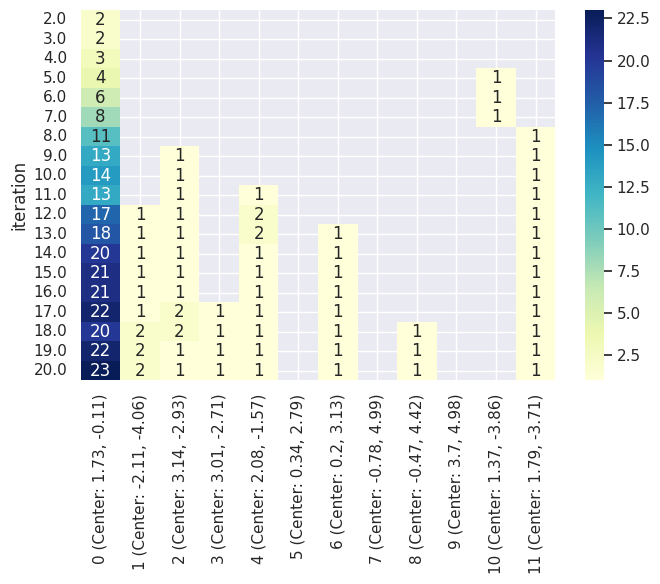

F22_I1 SADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0  5.562651e-03
1         1.0        1  5.562651e-03
2         1.0       12  5.562651e-03
3         2.0        0  5.562651e-03
4         2.0        5  5.562651e-03
..        ...      ...           ...
75       19.0       12  8.971728e-07
76       20.0        0  8.971728e-07
77       20.0        4  8.971728e-07
78       20.0        7  8.971728e-07
79       20.0       12  8.971728e-07

[80 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


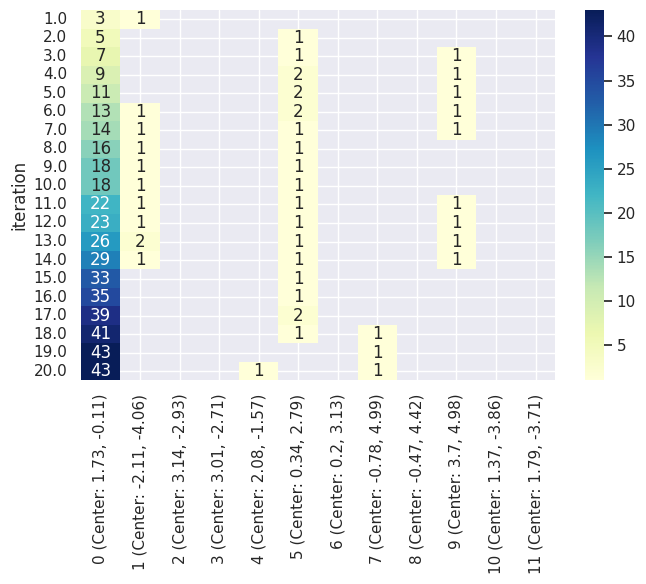

F22_I1 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.005585
1          1.0        5      0.005157
2          1.0       12      0.005157
3          2.0        0      0.001835
4          2.0        5      0.001835
..         ...      ...           ...
97        19.0       12      0.000001
98        20.0        0      0.000001
99        20.0        1      0.000001
100       20.0        2      0.000001
101       20.0       12      0.000001

[102 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


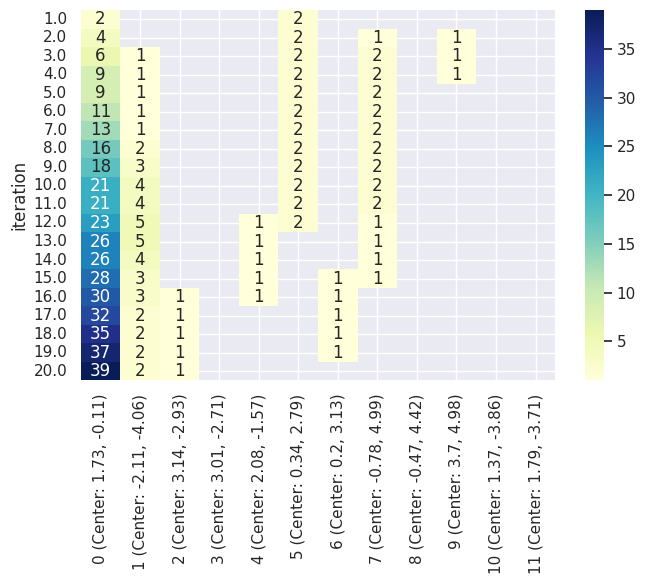

F22_I1 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  1.147716e-02
1          1.0        1  1.147716e-02
2          1.0       12  1.147716e-02
3          2.0        0  1.902050e-06
4          2.0        5  1.902050e-06
..         ...      ...           ...
96        20.0        1  5.236849e-07
97        20.0        5  5.236849e-07
98        20.0        6  5.236849e-07
99        20.0        8  5.236849e-07
100       20.0       12  5.236849e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


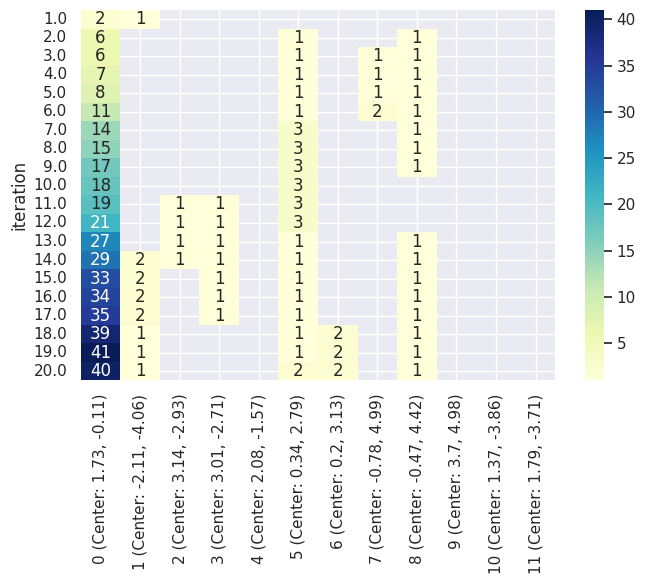

In [27]:
visualize([2], ['F22_I1'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_10_algorithms_dbscan', plot_y=False)

In [35]:
dimension=2
directory=f'data/clustering_features_10_algorithms_dbscan/cluster_distributions/dim_{dimension}'

trajectory_similarities=[]
for file in tqdm(os.listdir(directory)):
    file_loc=f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df=pd.read_csv(file_loc,index_col=[0,1,2])
        d_algorithm_run=df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
        trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]

trajectory_similarities=pd.concat(trajectory_similarities)
#t=trajectory_similarities.groupby('algorithm').count()['run']
#t_max=t.max()
#algorithms_to_remove=list(t[t<t_max].index)
#trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

100%|██████████| 120/120 [00:01<00:00, 102.48it/s]


In [36]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
408,AugmentedAEO,2,JADE,5,0.000000,F23_I2,23,2
824,JADE,3,OriginalDE,5,0.000000,F23_I2,23,2
822,HI_WOA,5,OriginalDE,5,0.000000,F23_I2,23,2
171,OriginalWOA,2,AugmentedAEO,4,0.000000,F19_I3,19,3
857,HI_WOA,3,OriginalSHADE,1,0.000000,F23_I2,23,2
...,...,...,...,...,...,...,...,...
939,ModifiedAEO,2,OriginalAEO,4,0.999911,F5_I1,5,1
855,ModifiedAEO,2,OriginalAEO,2,0.999915,F13_I4,13,4
650,OriginalAEO,2,ModifiedAEO,2,0.999915,F13_I4,13,4
962,AugmentedAEO,3,OriginalAEO,5,0.999931,F5_I3,5,3


100%|██████████| 120/120 [00:01<00:00, 74.99it/s]


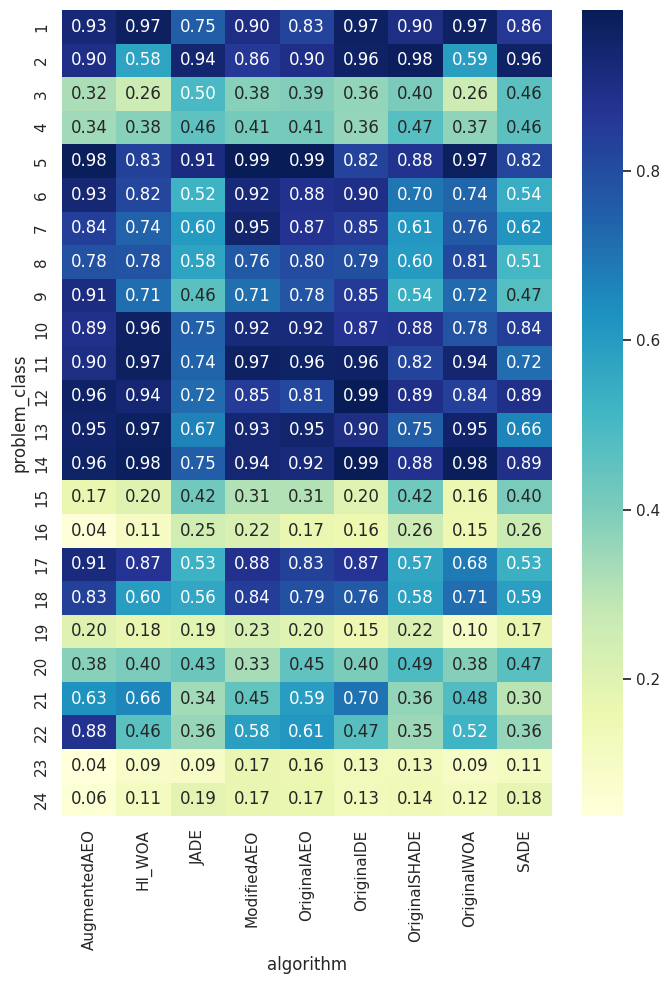

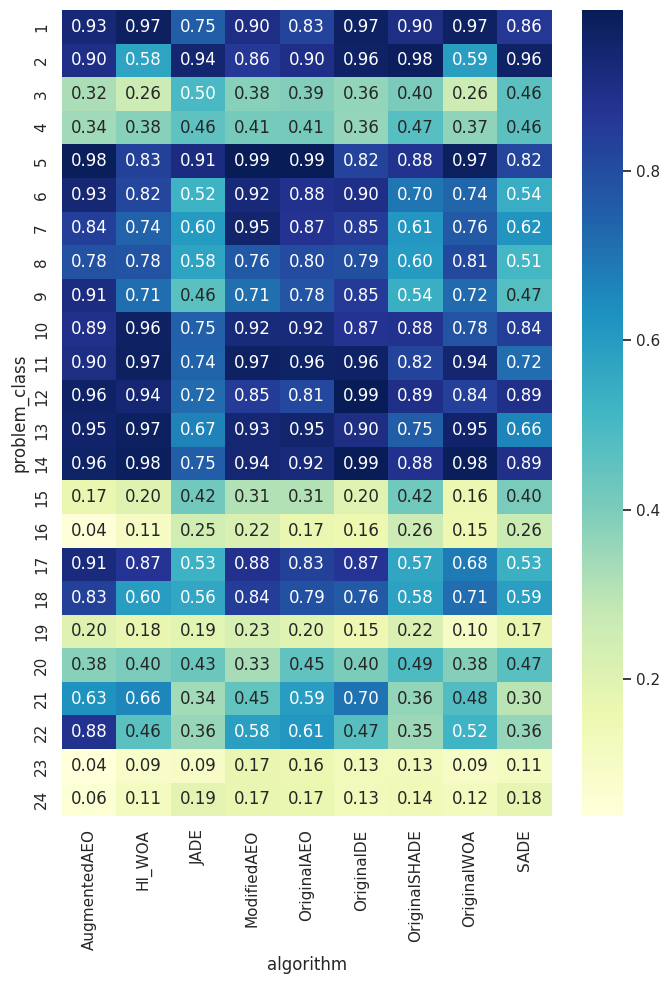

<Figure size 600x600 with 0 Axes>

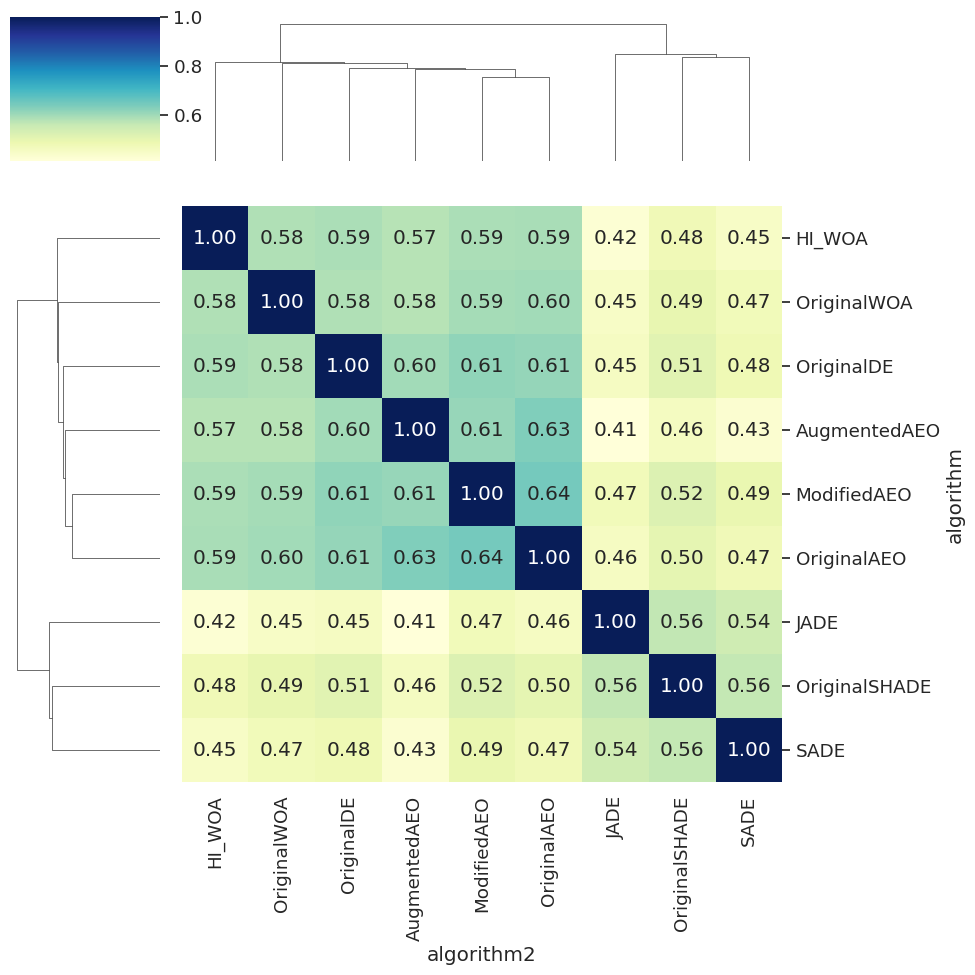

In [37]:
for dimension in [2]:
    directory=f'data/clustering_features_10_algorithms_dbscan/cluster_distributions/dim_{dimension}'
    scale=False
    trajectory_similarities=[]
    for file in tqdm(os.listdir(directory)):
        file_loc=f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df=pd.read_csv(file_loc,index_col=[0,1,2])
            d_algorithm_run=df.unstack(level=-1).dropna()
            d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
            trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]
    
    trajectory_similarities=pd.concat(trajectory_similarities)
    #t=trajectory_similarities.groupby('algorithm').count()['run']
    #t_max=t.max()
    #algorithms_to_remove=list(t[t<t_max].index)
    #trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf')


    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_stability_per_problem_dim_{dimension}_scale_{scale}.pdf')

    cross_algorithm_similarity=trajectory_similarities.query('run==run2').groupby(['algorithm','algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted=cross_algorithm_similarity.reset_index().pivot(index='algorithm',columns='algorithm2',values='value')
    sns.set(font_scale=1.2)
    plt.figure(figsize=(6,6))
    sns.clustermap(cross_algorithm_similarity_pivoted,annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf')
    sns.set(font_scale=1)


In [38]:
optimizer_group=get_algorithm_groups()


In [39]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'data/clustering_features_10_algorithms_dbscan/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [40]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

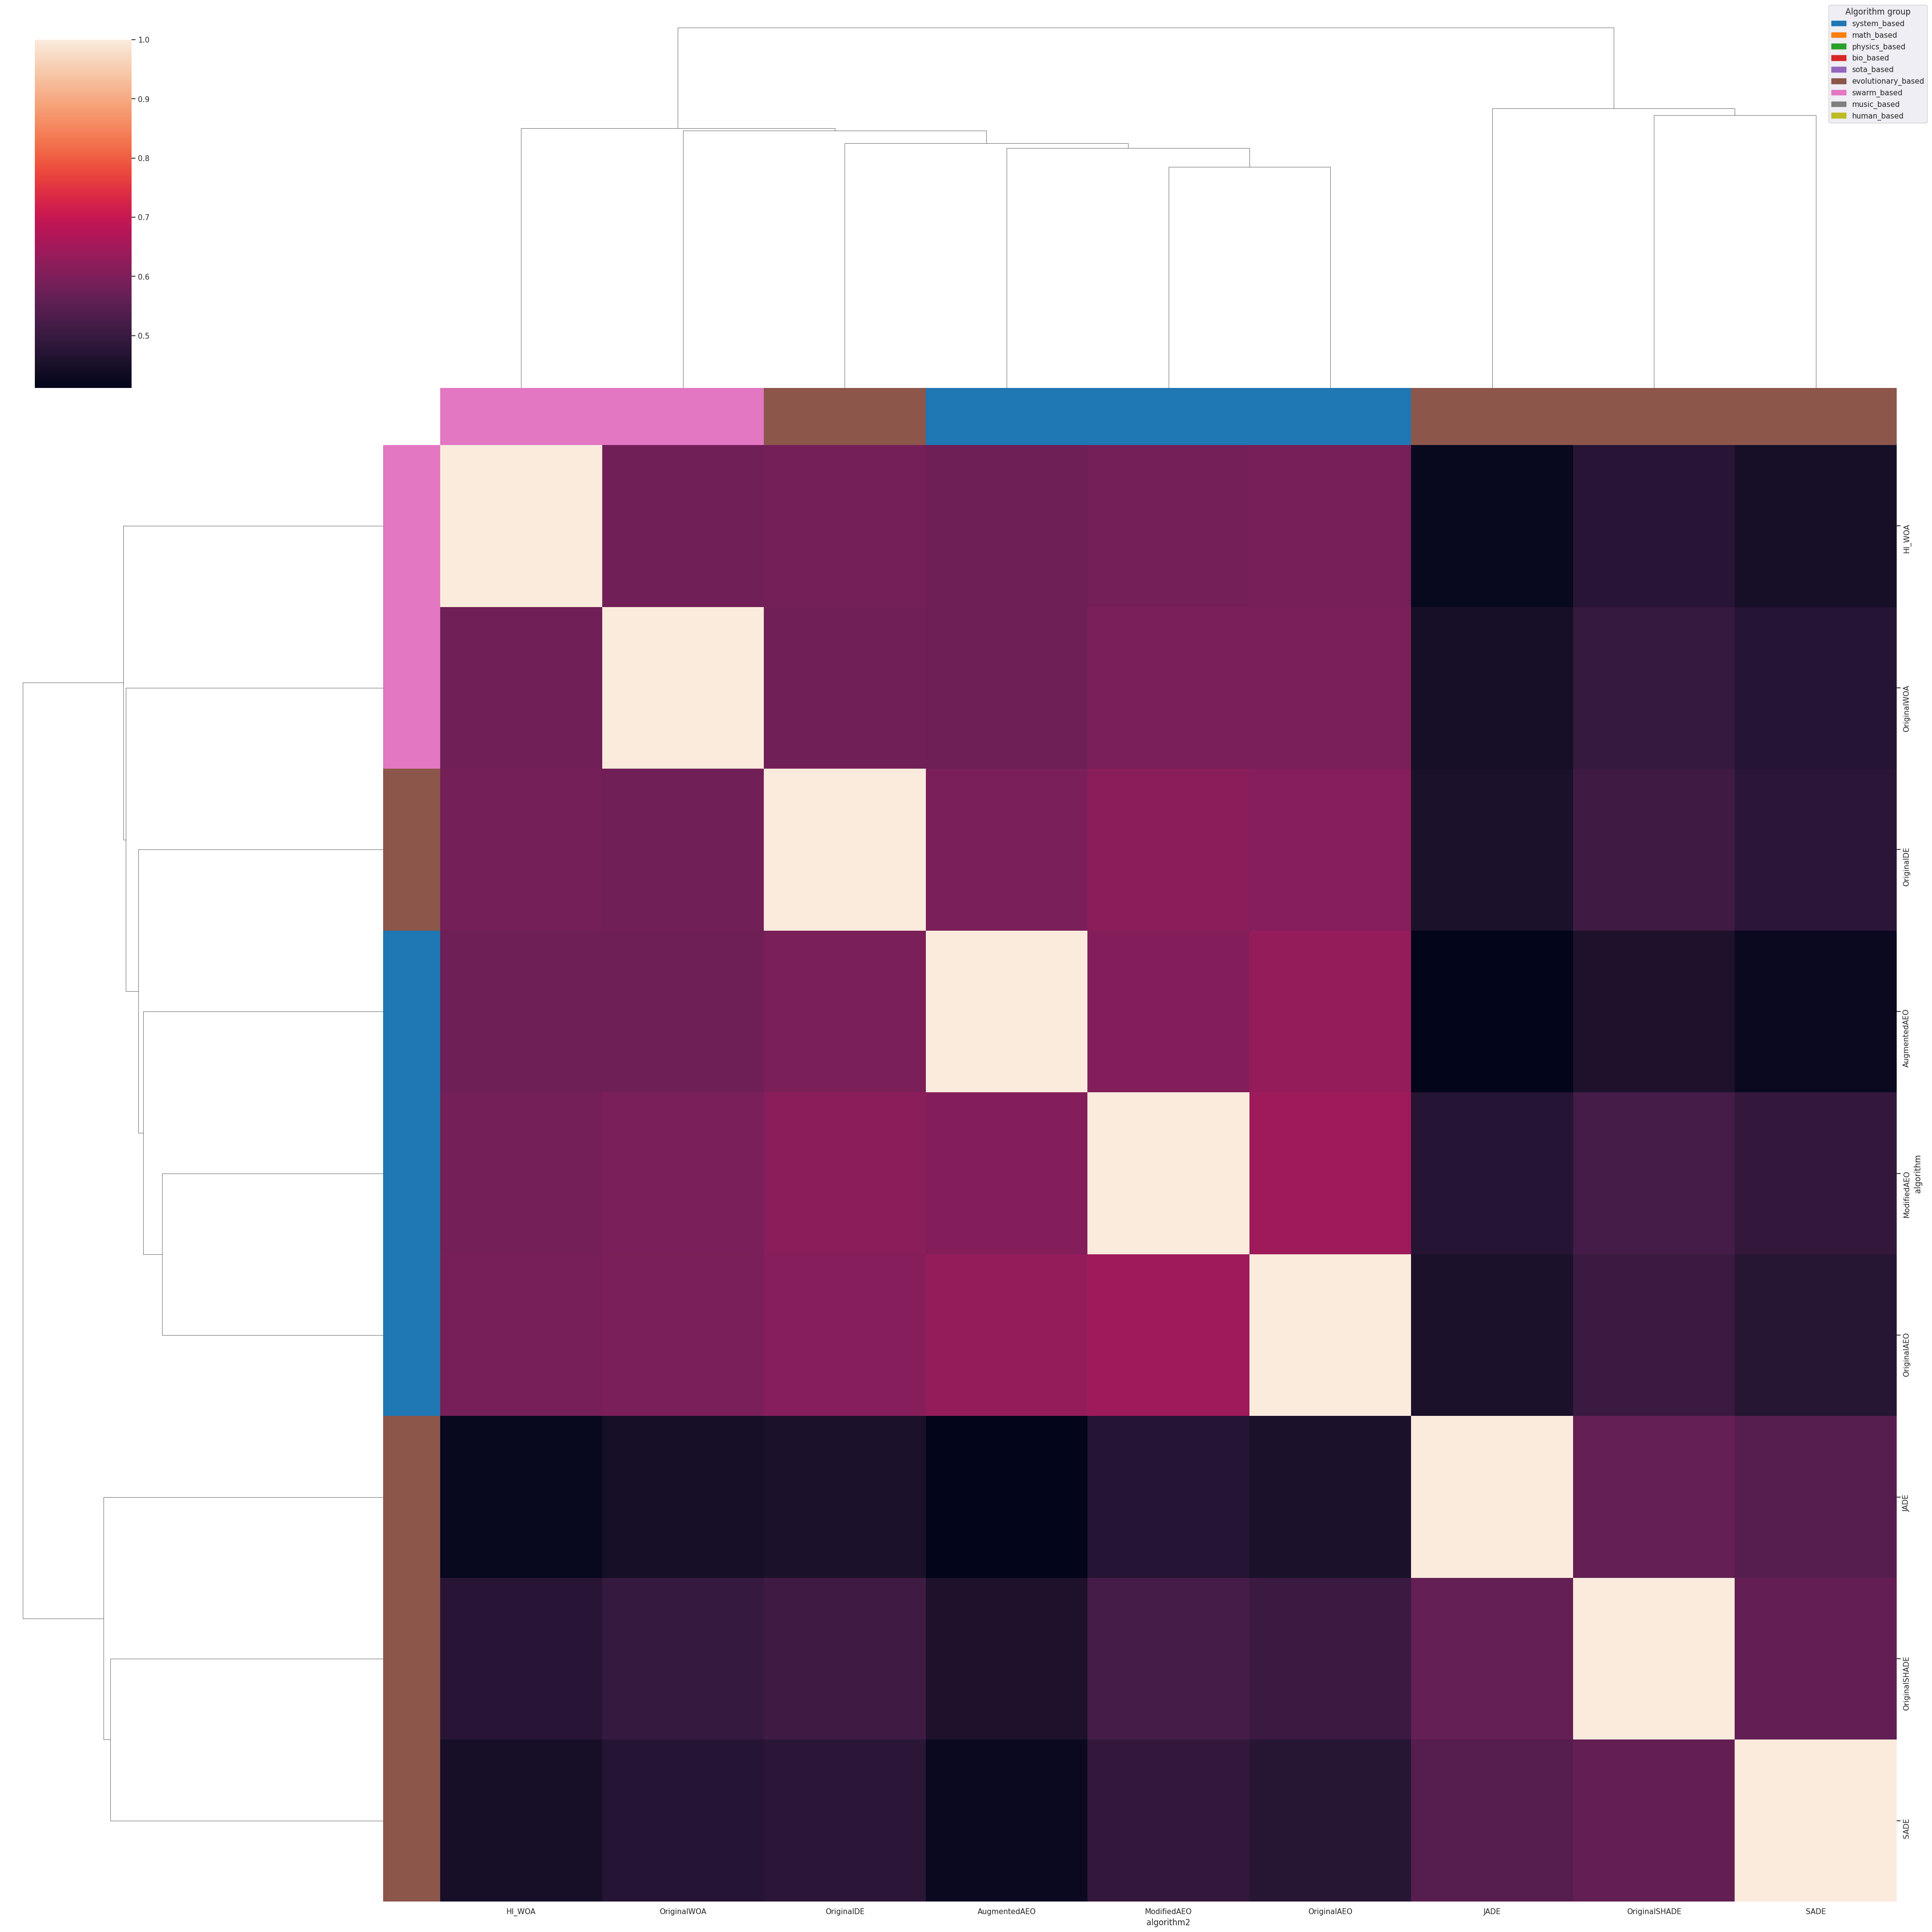

In [41]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering_dbscan/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
plt.show()
